<a href="https://colab.research.google.com/drive/1qqKQbXY_98Qt3yuGBCGv9jSe5ofNgsGI?usp=sharing" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg"
       alt="Open In Colab"/>
</a>

## Bank Mandiri

Import Dependencies

In [1]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.



Define Document

In [11]:
mandiri = """Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission (NZE) 2060 dengan menerima sertifikat dari IDXCarbon atas kontribusi aktifnya dalam peluncuran platform Perdagangan Karbon Internasional Indonesia. Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan sekaligus mendukung transisi Indonesia menuju ekonomi rendah karbon. Langkah strategis ini juga selaras dengan target perusahaan untuk mencapai Net Zero Emission Operasional pada 2030. Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5.000 tCO₂e kredit karbon yang dihasilkan dari proyek Conversion of Single Cycle to Combined Cycle on Power Plant. Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik dengan mengonversi sistem pembangkit siklus tunggal (PLTG) menjadi siklus gabungan (PLTGU).
"""

Text Preprocessing


In [3]:
import nltk
from nltk.tokenize import sent_tokenize

# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
# Sentence tokenization
sent_token3 = sent_tokenize(mandiri)
print(sent_token3)

['Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission (NZE) 2060 dengan menerima sertifikat dari IDXCarbon atas kontribusi aktifnya dalam peluncuran platform Perdagangan Karbon Internasional Indonesia.', 'Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan sekaligus mendukung transisi Indonesia menuju ekonomi rendah karbon.', 'Langkah strategis ini juga selaras dengan target perusahaan untuk mencapai Net Zero Emission Operasional pada 2030.', 'Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5.000 tCO₂e kredit karbon yang dihasilkan dari proyek Conversion of Single Cycle to Combined Cycle on Power Plant.', 'Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik dengan mengonversi sistem pembangkit siklus tunggal (PLTG) menjadi siklus gabungan (PLTGU).']


In [5]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.0 MB/s eta 0:00:00


In [7]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download the 'punkt' data if you haven't already
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

mandiri = """Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission (NZE) 2060 dengan menerima sertifikat dari IDXCarbon atas kontribusi aktifnya dalam peluncuran platform Perdagangan Karbon Internasional Indonesia. Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan sekaligus mendukung transisi Indonesia menuju ekonomi rendah karbon. Langkah strategis ini juga selaras dengan target perusahaan untuk mencapai Net Zero Emission Operasional pada 2030. Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5.000 tCO₂e kredit karbon yang dihasilkan dari proyek Conversion of Single Cycle to Combined Cycle on Power Plant. Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik dengan mengonversi sistem pembangkit siklus tunggal (PLTG) menjadi siklus gabungan (PLTGU).
"""
# Sentence tokenization
sent_token3 = sent_tokenize(mandiri)
print("Tokenized sentences:")
for sent in sent_token3:
    print(sent)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token3]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()  # Removed stop_words='english'
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)

# To see the feature names (the words in the vocabulary after Indonesian stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)

# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")

Tokenized sentences:
Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission (NZE) 2060 dengan menerima sertifikat dari IDXCarbon atas kontribusi aktifnya dalam peluncuran platform Perdagangan Karbon Internasional Indonesia.
Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan sekaligus mendukung transisi Indonesia menuju ekonomi rendah karbon.
Langkah strategis ini juga selaras dengan target perusahaan untuk mencapai Net Zero Emission Operasional pada 2030.
Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5.000 tCO₂e kredit karbon yang dihasilkan dari proyek Conversion of Single Cycle to Combined Cycle on Power Plant.
Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik dengan mengonversi sistem pembangkit siklus tunggal (PLTG) menjadi siklus gabungan (PLTGU).

Cleaned sentences (Indonesian stop words removed):
Bank Mandiri menunjukkan komitmennya mendukung upaya pemerintah menuju Net Zero 

Kalimat pertama setelah stopword removal:
Bank Mandiri menunjukkan komitmennya mendukung upaya pemerintah menuju Net Zero Emission (NZE) 2060 menerima sertifikat IDXCarbon atas kontribusi aktifnya peluncuran platform Perdagangan Karbon Internasional Indonesia.

TF-IDF untuk kalimat pertama:
          Feature    TF-IDF
2            2060  0.216925
3        aktifnya  0.216925
4            atas  0.216925
19  internasional  0.216925
17      idxcarbon  0.216925
35       menerima  0.216925
40    menunjukkan  0.216925
25     kontribusi  0.216925
23    komitmennya  0.216925
54       platform  0.216925
63     sertifikat  0.216925
73          upaya  0.216925
42            nze  0.216925
51    perdagangan  0.216925
48     pemerintah  0.216925
46     peluncuran  0.216925
18      indonesia  0.175014
34      mendukung  0.175014
41            net  0.175014
15       emission  0.175014
39         menuju  0.175014
74           zero  0.175014
5            bank  0.145277
21         karbon  0.145277
30      

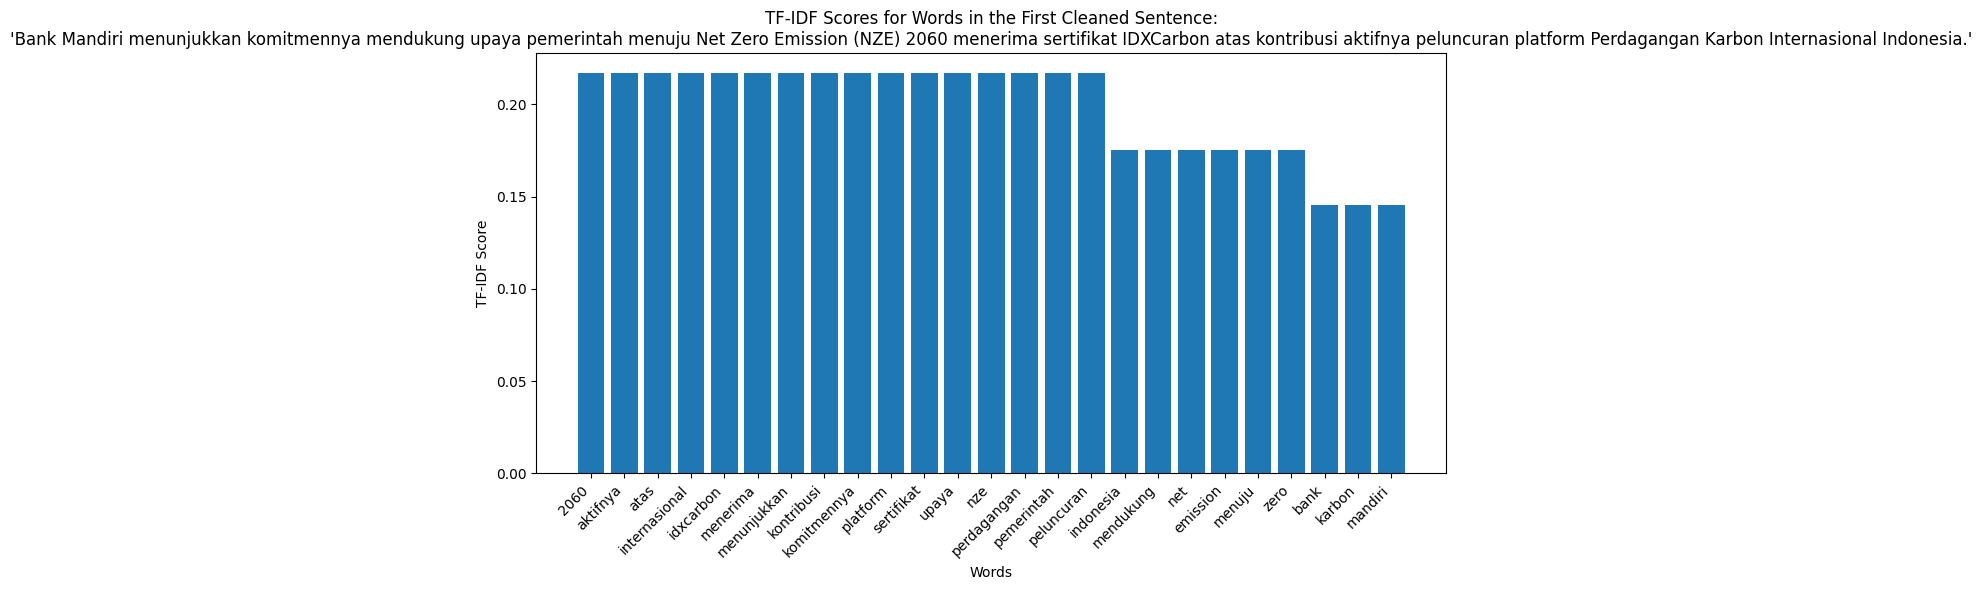

In [9]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import pandas as pd

# Download 'punkt' if needed
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

mandiri = """Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission (NZE) 2060 dengan menerima sertifikat dari IDXCarbon atas kontribusi aktifnya dalam peluncuran platform Perdagangan Karbon Internasional Indonesia. Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan sekaligus mendukung transisi Indonesia menuju ekonomi rendah karbon. Langkah strategis ini juga selaras dengan target perusahaan untuk mencapai Net Zero Emission Operasional pada 2030. Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5.000 tCO₂e kredit karbon yang dihasilkan dari proyek Conversion of Single Cycle to Combined Cycle on Power Plant. Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik dengan mengonversi sistem pembangkit siklus tunggal (PLTG) menjadi siklus gabungan (PLTGU).
"""

# Sentence tokenization
sent_token3 = sent_tokenize(mandiri)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token3]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

# Fungsi ambil TF-IDF per kalimat
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
    tfidf_df = pd.DataFrame({
        'Feature': feature_names,
        'TF-IDF': sentence_tfidf_values
    })
    tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return tfidf_df

# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    print("Kalimat pertama setelah stopword removal:")
    print(first_cleaned_sentence)

    print("\nTF-IDF untuk kalimat pertama:")
    print(first_sentence_tfidf_df)

    # Visualize the TF-IDF scores
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

Calculate Sentence Score

**List of Sentences:**
1. Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission (NZE) 2060 dengan menerima sertifikat dari IDXCarbon atas kontribusi aktifnya dalam peluncuran platform Perdagangan Karbon Internasional Indonesia.
2. Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan sekaligus mendukung transisi Indonesia menuju ekonomi rendah karbon.
3. Langkah strategis ini juga selaras dengan target perusahaan untuk mencapai Net Zero Emission Operasional pada 2030.
4. Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5.000 tCO₂e kredit karbon yang dihasilkan dari proyek Conversion of Single Cycle to Combined Cycle on Power Plant.
5. Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik dengan mengonversi sistem pembangkit siklus tunggal (PLTG) menjadi siklus gabungan (PLTGU).

-------------------------

**Average TF-IDF Score for Each Sentence:**
- Sentence 1
  Sum of TF-IDF scores: 4.9567

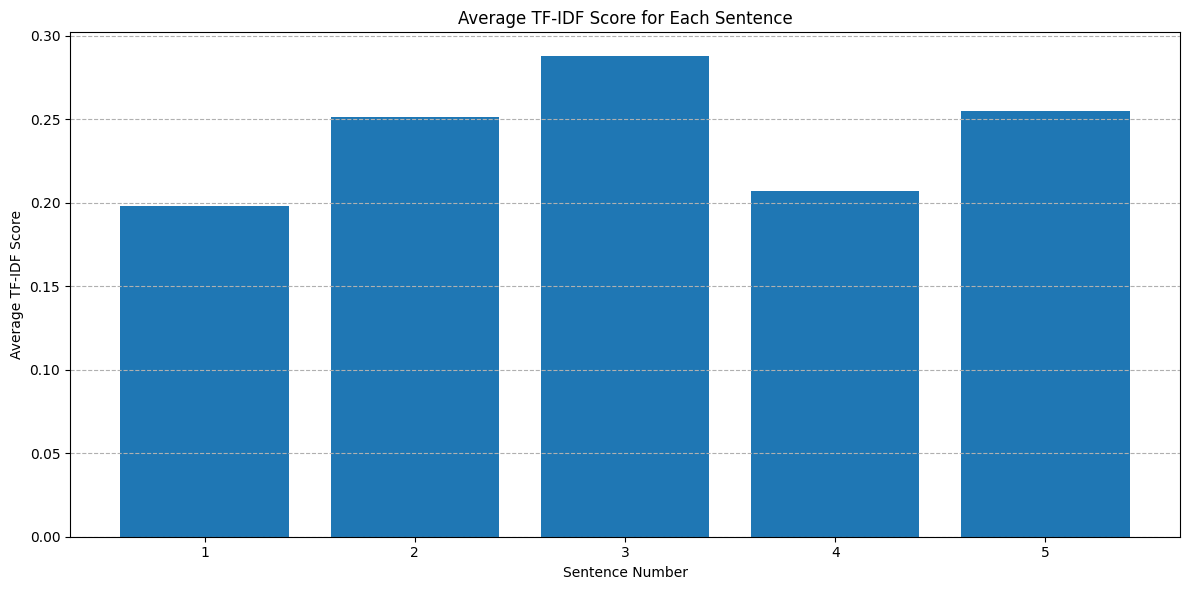


**Explanation of the Histogram :**
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

**What does the height of the bar tell us?**
- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less c

In [10]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
mandiri = """Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission (NZE) 2060 dengan menerima sertifikat dari IDXCarbon atas kontribusi aktifnya dalam peluncuran platform Perdagangan Karbon Internasional Indonesia. Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan sekaligus mendukung transisi Indonesia menuju ekonomi rendah karbon. Langkah strategis ini juga selaras dengan target perusahaan untuk mencapai Net Zero Emission Operasional pada 2030. Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5.000 tCO₂e kredit karbon yang dihasilkan dari proyek Conversion of Single Cycle to Combined Cycle on Power Plant. Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik dengan mengonversi sistem pembangkit siklus tunggal (PLTG) menjadi siklus gabungan (PLTGU).
"""
# Sentence tokenization
sent_token3 = sent_tokenize(mandiri)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token3]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token3):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Explanation:
print("\n**Explanation of the Histogram :**")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n**What does the height of the bar tell us?**")
print("- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")


Define Threshold

In [12]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

mandiri = """Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission (NZE) 2060 dengan menerima sertifikat dari IDXCarbon atas kontribusi aktifnya dalam peluncuran platform Perdagangan Karbon Internasional Indonesia. Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan sekaligus mendukung transisi Indonesia menuju ekonomi rendah karbon. Langkah strategis ini juga selaras dengan target perusahaan untuk mencapai Net Zero Emission Operasional pada 2030. Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5.000 tCO₂e kredit karbon yang dihasilkan dari proyek Conversion of Single Cycle to Combined Cycle on Power Plant. Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik dengan mengonversi sistem pembangkit siklus tunggal (PLTG) menjadi siklus gabungan (PLTGU).
"""
# Sentence tokenization
sent_token3 = sent_tokenize(mandiri)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token3]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_scores = []

# Calculate sentence TF-IDF score
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.23974562598339114


In [15]:
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import math
import re

# Download tokenizer
nltk.download('punkt')

# Stopword remover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

sentences = [
    "Jakarta -- Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission 2060.",
    "Komitmen ini ditunjukkan dengan menerima sertifikat dari IDXCarbon atas kontribusi aktif dalam peluncuran platform perdagangan karbon internasional Indonesia.",
    "Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan.",
    "Selain itu, langkah ini juga mendukung transisi Indonesia menuju ekonomi rendah karbon.",
    "Strategi ini selaras dengan target perusahaan untuk mencapai Net Zero Emission operasional pada tahun 2030.",
    "Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5000 tCO2e kredit karbon.",
    "Kredit karbon tersebut berasal dari proyek konversi pembangkit listrik dari single cycle menjadi combined cycle.",
    "Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik.",
    "Konversi dari PLTG ke PLTGU dilakukan untuk menghasilkan energi yang lebih efisien.",
    "Langkah ini diharapkan dapat mengurangi emisi karbon secara signifikan."
]

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # hapus angka & tanda baca
    text = stopword_remover.remove(text)
    return text

all_cleaned_sentences = [clean_text(s) for s in sentences]

print("Hasil cleaning:")
for s in all_cleaned_sentences:
    print(s)

def calculate_tf(term, document):
    words = word_tokenize(document)
    return words.count(term) / len(words) if len(words) > 0 else 0

def calculate_idf(term, documents):
    count = sum(1 for doc in documents if term in word_tokenize(doc))
    return math.log(len(documents) / count) if count > 0 else 0

tfidf_scores = {}

for i, sentence in enumerate(all_cleaned_sentences):
    tf = calculate_tf("karbon", sentence)
    idf = calculate_idf("karbon", all_cleaned_sentences)
    tfidf_scores[f"Kalimat {i+1}"] = tf * idf

print("\nTF-IDF Score untuk 'karbon':\n")
for k, v in tfidf_scores.items():
    print(f"{k}: {v:.4f}")

idf_total = calculate_idf("karbon", all_cleaned_sentences)
print(f"\nOverall IDF 'karbon': {idf_total:.4f}")

Hasil cleaning:
jakarta  bank mandiri menunjukkan komitmennya mendukung upaya pemerintah menuju net zero emission 
komitmen ditunjukkan menerima sertifikat idxcarbon atas kontribusi aktif peluncuran platform perdagangan karbon internasional indonesia
penghargaan memperkuat peran bank mandiri mendukung keberlanjutan lingkungan
itu langkah juga mendukung transisi indonesia menuju ekonomi rendah karbon
strategi selaras target perusahaan mencapai net zero emission operasional tahun 
bentuk dukungan konkret bank mandiri membeli  tcoe kredit karbon
kredit karbon tersebut berasal proyek konversi pembangkit listrik single cycle menjadi combined cycle
proyek bertujuan meningkatkan efisiensi pembangkit listrik
konversi pltg pltgu dilakukan menghasilkan energi lebih efisien
langkah diharapkan mengurangi emisi karbon signifikan

TF-IDF Score untuk 'karbon':

Kalimat 1: 0.0000
Kalimat 2: 0.0495
Kalimat 3: 0.0000
Kalimat 4: 0.0693
Kalimat 5: 0.0000
Kalimat 6: 0.0770
Kalimat 7: 0.0533
Kalimat 8: 0.00

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [16]:
#threshold = sum(sent_scores)/len(sent_scores) # Average of Sentence Scores
#threshold


Get Sentences

In [18]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

mandiri = """Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission 2060.
Komitmen ini ditunjukkan dengan menerima sertifikat dari IDXCarbon atas kontribusi aktif dalam peluncuran platform perdagangan karbon internasional Indonesia.
Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan.
Selain itu, langkah ini juga mendukung transisi Indonesia menuju ekonomi rendah karbon.
Strategi ini selaras dengan target perusahaan untuk mencapai Net Zero Emission operasional pada tahun 2030.
Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5000 tCO2e kredit karbon.
Kredit karbon tersebut berasal dari proyek konversi pembangkit listrik dari single cycle menjadi combined cycle.
Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik.
Konversi dari PLTG ke PLTGU dilakukan untuk menghasilkan energi yang lebih efisien.
Langkah ini diharapkan dapat mengurangi emisi karbon secara signifikan.
"""

# Sentence tokenization
sent_token3 = sent_tokenize(mandiri)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token3]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_scores = []

# Calculate average TF-IDF score for each sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

# Final summary initialization
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token3[index]
        print(f"- {sent_token3[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.3236554107661081

**Summary Sentences (above or equal to the threshold):**
- Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan.
- Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik.
- Konversi dari PLTG ke PLTGU dilakukan untuk menghasilkan energi yang lebih efisien.
- Langkah ini diharapkan dapat mengurangi emisi karbon secara signifikan.

**Final Summary:**
Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan. Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik. Konversi dari PLTG ke PLTGU dilakukan untuk menghasilkan energi yang lebih efisien. Langkah ini diharapkan dapat mengurangi emisi karbon secara signifikan.


In [19]:
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import math

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

mandiri = [
    "Bank Mandiri kembali menunjukkan komitmennya dalam mendukung upaya pemerintah menuju Net Zero Emission 2060.",
    "Komitmen ini ditunjukkan dengan menerima sertifikat dari IDXCarbon atas kontribusi aktif dalam peluncuran platform perdagangan karbon internasional Indonesia.",
    "Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan.",
    "Selain itu, langkah ini juga mendukung transisi Indonesia menuju ekonomi rendah karbon.",
    "Strategi ini selaras dengan target perusahaan untuk mencapai Net Zero Emission operasional pada tahun 2030.",
    "Sebagai bentuk dukungan konkret, Bank Mandiri membeli 5000 tCO2e kredit karbon.",
    "Kredit karbon tersebut berasal dari proyek konversi pembangkit listrik dari single cycle menjadi combined cycle.",
    "Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik.",
    "Konversi dari PLTG ke PLTGU dilakukan untuk menghasilkan energi yang lebih efisien.",
    "Langkah ini diharapkan dapat mengurangi emisi karbon secara signifikan."
]

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "karbon" in each sentence
tfidf_scores = {}
all_cleaned_sentences = []

for sentence in sentences:
    cleaned_sentence = stopword_remover.remove(sentence)
    all_cleaned_sentences.append(cleaned_sentence)

for i, sentence in enumerate(sentences):
    cleaned_sentence = stopword_remover.remove(sentence)
    tf = calculate_tf("karbon", cleaned_sentence)
    idf = calculate_idf("karbon", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "karbon" in each sentence
print("TF-IDF Score for 'karbon' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "karbon" across all cleaned sentences
overall_idf_karbon = calculate_idf("karbon", all_cleaned_sentences)
print(f"\nOverall IDF for 'karbon': {overall_idf_karbon:.4f}")

# Direct approach with TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words=factory.get_stop_words())
tfidf_matrix = vectorizer.fit_transform(sentences)
feature_names = vectorizer.get_feature_names_out()

try:
    karbon_index = list(feature_names).index("karbon")
    print("\nTF-IDF Score for 'karbon' using TfidfVectorizer:")
    for i, sentence in enumerate(sentences):
        tfidf = tfidf_matrix[i, karbon_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'karbon' not found in the vocabulary after stop word removal by TfidfVectorizer.")

TF-IDF Score for 'karbon' in each sentence:
Sentence 1: 0.0000
Sentence 2: 0.0462
Sentence 3: 0.0000
Sentence 4: 0.0533
Sentence 5: 0.0000
Sentence 6: 0.0533
Sentence 7: 0.0495
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0990

Overall IDF for 'karbon': 0.6931

TF-IDF Score for 'karbon' using TfidfVectorizer:
Sentence 1: 0.0000
Sentence 2: 0.1642
Sentence 3: 0.0000
Sentence 4: 0.2410
Sentence 5: 0.0000
Sentence 6: 0.2076
Sentence 7: 0.1649
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.2636


In [20]:
final_summ

' Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan. Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik. Konversi dari PLTG ke PLTGU dilakukan untuk menghasilkan energi yang lebih efisien. Langkah ini diharapkan dapat mengurangi emisi karbon secara signifikan.'

In [21]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token3[index]
    print("- ", sent_token3[index])

-  Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan.
-  Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik.
-  Konversi dari PLTG ke PLTGU dilakukan untuk menghasilkan energi yang lebih efisien.
-  Langkah ini diharapkan dapat mengurangi emisi karbon secara signifikan.



Summarization Result

In [22]:
final_summ

' Penghargaan ini memperkuat peran Bank Mandiri dalam mendukung keberlanjutan lingkungan. Proyek ini bertujuan meningkatkan efisiensi pembangkit listrik. Konversi dari PLTG ke PLTGU dilakukan untuk menghasilkan energi yang lebih efisien. Langkah ini diharapkan dapat mengurangi emisi karbon secara signifikan.'